# Stage 4 — Intrinsic Karst Vulnerability (Mole Creek prototype)

Combines Stage 2 (karst susceptibility) and Stage 3 (hydrological
connectivity) into **intrinsic karst vulnerability**. This answers: *"if something happens on the surface,
where is the underlying karst system relatively more vulnerable?"*

**Combination method:** Karst susceptibility × Hydrological connectivity
(multiplicative, not a weighted sum) — per the revised workflow plan,
matching COP's own multiplicative design (see the Framework section of
the project scope doc). Each input is normalised to 0-1 by its own
maximum before multiplying, so neither dominates just because of its
raw scale (intensity 0-4 vs. connectivity 0-3).

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

sys.path.insert(0, str(Path("..") / "src"))
from karst import classify_scores

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
    profile = src.profile
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    connectivity = src.read(1).astype(float)
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1)
    dem_nodata = src.nodata

valid = dem != dem_nodata

## 4.1 Normalise and combine

In [2]:
intensity_norm = intensity / 4.0       # max KCATEGORY score from Stage 2
connectivity_norm = connectivity / 3.0  # max connectivity score from Stage 3

intrinsic = intensity_norm * connectivity_norm
intrinsic[~valid] = np.nan

print("Distinct combined score values present:", np.unique(intrinsic[valid]))

Distinct combined score values present: [0.         0.25       0.5        0.66666667 0.75       1.        ]


## 4.2 Classify

Classified directly on whatever distinct combined values actually occur
(via `classify_scores()` in `src/karst.py`), not arbitrary quantile
breaks -- with only a handful of discrete ordinal inputs, there are only
ever a few real combinations. **Fixed after review:** this used to be a
hardcoded 4-value dict; when Stage 3's connectivity scoring was revised
(covered karst no longer scores identically to exposed), two new score
values appeared and were silently dropped as nodata by the old hardcoded
version. The shared helper classifies on whatever actually occurs, so a
change upstream can't silently break this step again.

Class distribution (valid cells):
  None (score=0.0000): 1431277 cells (77.4%)
  Very Low (score=0.2500): 27524 cells (1.5%)
  Low-Moderate (score=0.5000): 100544 cells (5.4%)
  Moderate-High (score=0.6667): 152787 cells (8.3%)
  Very High (score=0.7500): 32232 cells (1.7%)
  Extreme (score=1.0000): 104046 cells (5.6%)


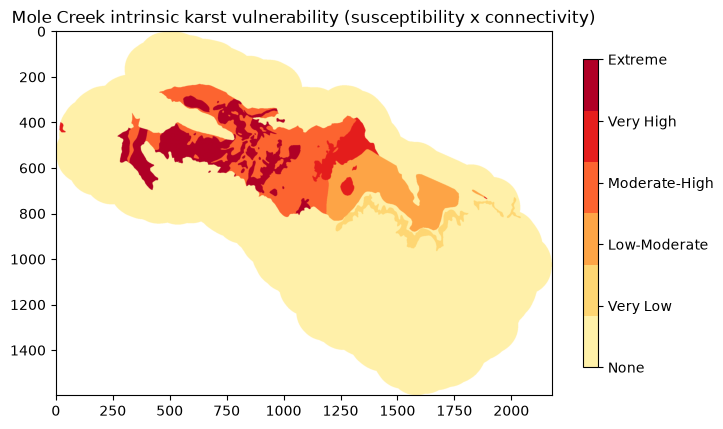

In [3]:
intrinsic_class, present, LABELS = classify_scores(intrinsic, valid)

print("Class distribution (valid cells):")
for i, (val, label) in enumerate(zip(present, LABELS)):
    n = (intrinsic_class == i).sum()
    print(f"  {label} (score={val:.4f}): {n} cells ({n/valid.sum()*100:.1f}%)")

out_profile = profile.copy()
out_profile.update(dtype="uint8", nodata=255)
with rasterio.open(outpath / "intrinsic_vulnerability_mc_EPSG7855.tif", "w", **out_profile) as dst:
    dst.write(intrinsic_class, 1)

# Also save the continuous (unclassified) score -- Stage 6 needs the real
# relative spacing, not the class index, which would distort it
intrinsic_raw = np.where(valid, intrinsic, -9999).astype("float32")
raw_profile = profile.copy()
raw_profile.update(dtype="float32", nodata=-9999)
with rasterio.open(outpath / "intrinsic_vulnerability_raw_mc_EPSG7855.tif", "w", **raw_profile) as dst:
    dst.write(intrinsic_raw, 1)

cmap = ListedColormap(plt.cm.YlOrRd(np.linspace(0.1, 0.9, len(present))))
display = np.ma.masked_equal(intrinsic_class, 255)
plt.figure(figsize=(8, 8))
plt.imshow(display, cmap=cmap, vmin=0, vmax=len(present) - 1)
cbar = plt.colorbar(ticks=range(len(present)), shrink=0.5)
cbar.ax.set_yticklabels(LABELS)
plt.title("Mole Creek intrinsic karst vulnerability (susceptibility x connectivity)")
plt.show()


## An honest finding: connectivity still under-differentiates at Mole Creek, less than before

After revising Stage 3's scoring (covered karst no longer scores
identically to exposed), the combined score now has real variation from
connectivity, not just susceptibility -- 6 distinct combined values
instead of 4. It's a genuine improvement, not a full fix: Mole Creek is
still a small, thoroughly-mapped area where most karst polygons carry a
connectivity-elevating attribute one way or another, so this study area
still doesn't exercise the full range either factor could take.

Worth stating in `discussion.md`: this is a property of Mole Creek's
data completeness (heavily surveyed), not of the method itself. Stage 7
(statewide) shows connectivity varying genuinely more, since not every
mapped karst area has a proximal catchment assigned.

## Stage 4 outputs

- `intrinsic_vulnerability_mc_EPSG7855.tif` -- classified intrinsic vulnerability (labels generated from whatever values actually occur -- see printed output above, not hardcoded here since that's exactly what broke last time)
- `intrinsic_vulnerability_raw_mc_EPSG7855.tif` -- continuous (unclassified) score, used by Stage 6

**Next (Stage 5):** land-use pressure from DEA Level-3 land cover -- the
first layer that should actually show variation *outside* the karst
polygons themselves, now that the Mole Creek boundary includes real
surrounding land (see the buffer fix in Stage 0).